# Notebook 02 — Baseline Model (Seasonal Naive)

**Goal:** Establish a simple baseline that all other models must beat.

The Seasonal Naive forecast = the value from the same month one year ago.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_loader import get_monthly_total, train_test_split
from evaluation import evaluate

plt.rcParams['figure.figsize'] = (14, 6)

## Step 1: Load data and split into train/test

- **Train:** Jan 2018 – Dec 2024
- **Test:** Jan 2025 – Mar 2026

In [2]:
y = get_monthly_total('../data/Tourism_MOM_Dataset.csv')
train, test = train_test_split(y, '2025-01-01')
print(f'Train: {len(train)} months')
print(f'Test:  {len(test)} months')

Train: 84 months
Test:  15 months


## Step 2: Seasonal Naive forecast

In [3]:
sn = pd.Series([y.iloc[y.index.get_loc(d) - 12] for d in test.index], index=test.index)
result = evaluate(test, sn, 'Seasonal Naive')

Seasonal Naive                  MAE=   27,869  RMSE=   29,655  MAPE= 14.19%


## Step 3: Plot

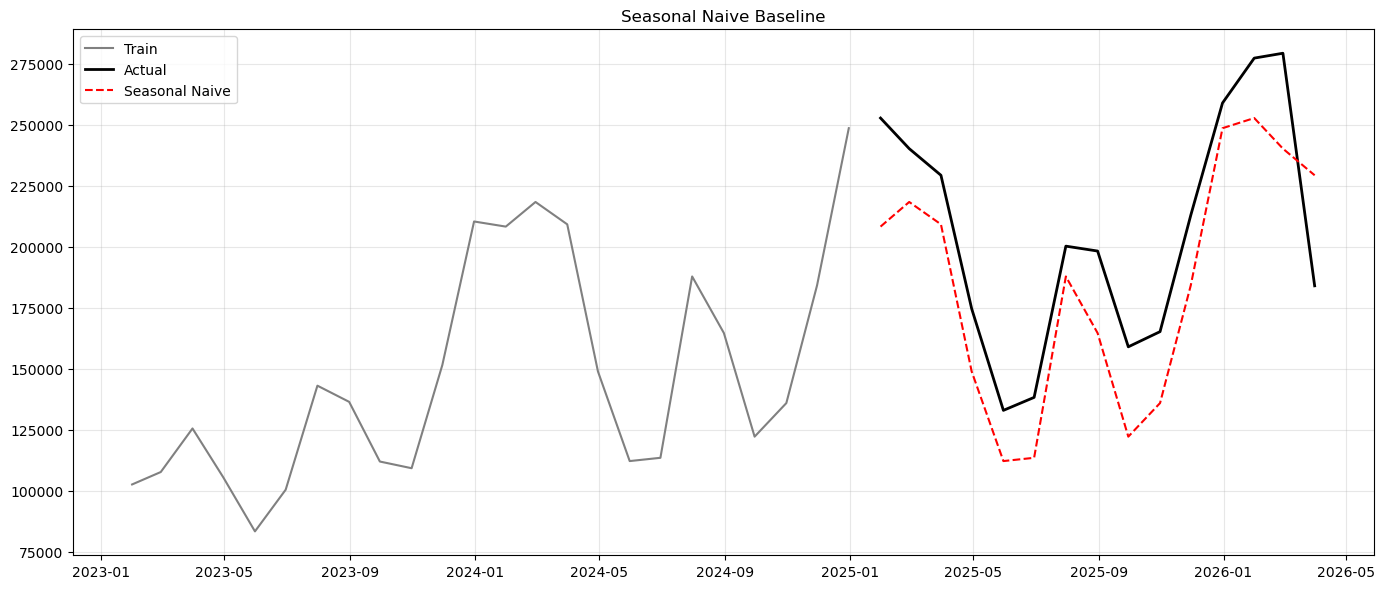

In [4]:
plt.figure()
plt.plot(train.index[-24:], train.values[-24:], label='Train', color='gray')
plt.plot(test.index, test.values, label='Actual', color='black', linewidth=2)
plt.plot(test.index, sn.values, label='Seasonal Naive', linestyle='--', color='red')
plt.title('Seasonal Naive Baseline'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('../results/02_seasonal_naive.png', dpi=150); plt.show()

## Step 4: Save result

In [5]:
pd.DataFrame([result]).to_csv('../results/model_results.csv', index=False)
print('Saved. Move to 03_sarima_models.ipynb')

Saved. Move to 03_sarima_models.ipynb
